In [6]:
import pandas as pd
from google.cloud import bigquery
import seaborn as sns
import numpy as np

df = pd.read_csv(r'C:\Users\divye\Data_science_projects\500_restaurants_analysis\data\restaurants_features.csv')
df.head()


,Restaurant_ID,Restaurant_Name,City,city_avg_rating,Cuisines,num_cuisines,AC_of_Two_imputed,Price_Range,price_cat,weighted_ranking,value_money_score,value_percentile,value_segment_money_score,convenience_score,popularity_level,Agg_rating,Rating_text,Rating_color,Votes,log_votes
0,3326,The Mirch Masala,New Delhi,2.860136,North Indian,1,650,2,Moderate,2.743101,0.004923,0.472568,Moderate,0,Low,3.2,Average,Orange,22,3.135494
1,6286,Bengali Pastry Shop & Snack Bar,New Delhi,2.860136,"North Indian, South Indian, Chinese",3,550,2,Moderate,2.852211,0.005818,0.548529,Acceptable,0,Medium,3.2,Average,Orange,70,4.262680
2,7352,Domino's Pizza,New Delhi,2.860136,"Pizza, Fast Food",2,700,2,Moderate,2.924409,0.004714,0.456340,Moderate,0,Medium,3.3,Average,Orange,90,4.510860
3,18483372,Sky On 57,Singapore,2.845674,"Chinese, Continental, Singaporean",3,300,4,Premium,2.817542,0.011333,0.805151,Good,0,Low,3.4,Average,Orange,34,3.555348
4,4166,Red - Bellagio,New Delhi,2.860136,Chinese,1,1500,3,Expensive,3.041397,0.002267,0.279447,Moderate,2,Medium,3.4,Average,Orange,137,4.927254


<Axes: xlabel='price_cat', ylabel='Agg_rating'>

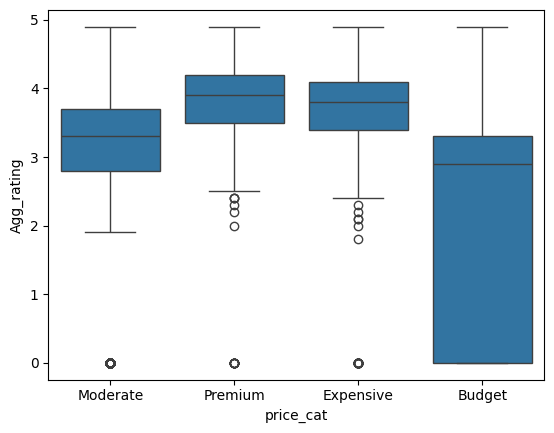

In [ ]:

sns.boxplot(x='price_cat',y='Agg_rating',data = df)

Budget restaurants exhibit the widest variation in customer ratings, with a median rating below 3.0, indicating inconsistent customer experiences.

Moderate‑priced restaurants show a narrower and more stable rating distribution, with most ratings ranging between 2.5 and 4.0.

Expensive restaurants demonstrate a relatively concentrated rating range, with approximately half of the restaurants rated between 3.0 and 4.0, though a few low‑rating outliers are present.

Premium restaurants display a similar pattern to the Expensive category, with a slightly higher median rating, suggesting marginally better perceived quality, while still exhibiting a small number of low‑rating outliers.

<Axes: xlabel='price_cat', ylabel='value_percentile'>

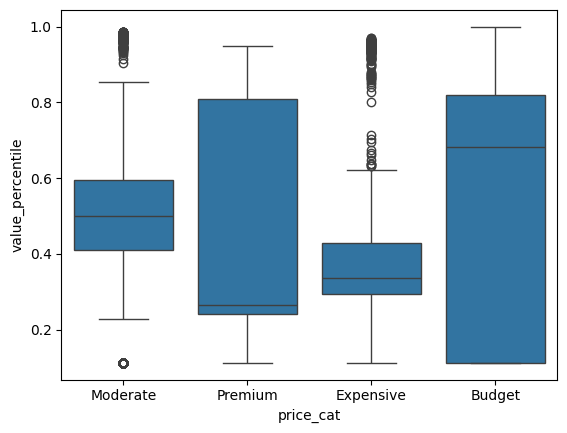

In [8]:
sns.boxplot(x='price_cat', y='value_percentile', data=df)

Budget restaurants exhibit the widest variation in value‑for‑money percentiles, with a relatively high median around 0.65–0.7, indicating that many budget establishments deliver strong value despite inconsistent performance across the category.

Moderate‑priced restaurants show a narrow and stable distribution, with a median value percentile around 0.5 and the central 50% of restaurants clustered between approximately 0.4 and 0.6. This suggests consistent value perception within this price range, with a few high‑value and low‑value outliers.

Expensive restaurants display a relatively tight distribution with a lower median value percentile near 0.3, indicating that higher prices do not generally translate into better relative value, although a small number of high‑performing outliers exist.

Premium restaurants demonstrate the most variability after the Budget category, with a low median value percentile around 0.25 but several high‑value outliers. This suggests that while most premium restaurants offer lower relative value, a limited subset delivers exceptional performance relative to cost.

<Axes: xlabel='Votes', ylabel='Agg_rating'>

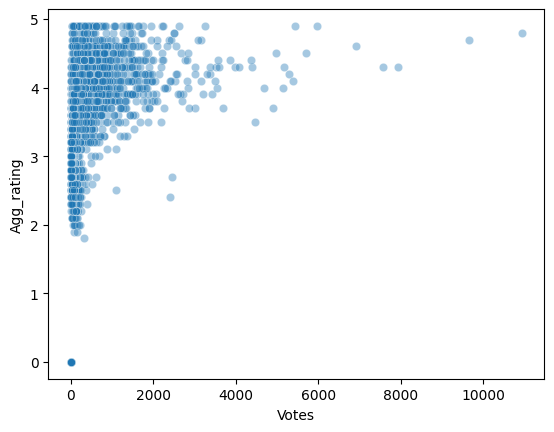

In [12]:
sns.scatterplot(x='Votes',y='Agg_rating', data=df,alpha=0.4)

The scatter plot reveals a clear relationship between vote count and rating reliability. Restaurants with fewer votes exhibit a wide range of ratings, including extreme values, indicating higher uncertainty. As vote counts increase, ratings become more stable and converge within a narrower range, suggesting greater reliability. This pattern justifies the use of vote‑weighted ratings to reduce bias from low‑review restaurants.

<Axes: xlabel='convenience_score', ylabel='Agg_rating'>

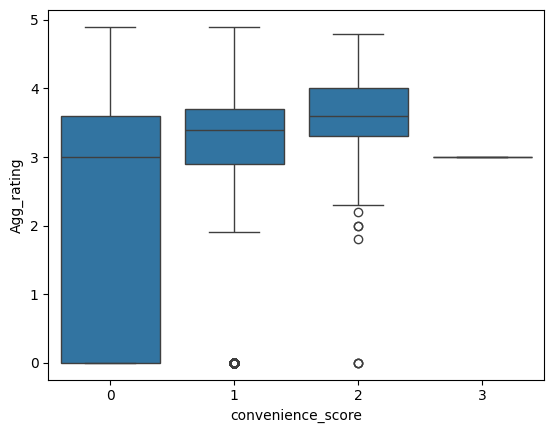

In [10]:
sns.boxplot(x='convenience_score', y='Agg_rating', data=df)

The Restaurants with no service given exhibits wide spread between 0.0 and 3.6 ratings nearly. The median of the entities is 3.0. Fewer numbers are showing above a 4.0 rating.

The score with 1 has a narrow spread with a median of nearly 3.4. The range stays between 3.0 and 3.5 ratings. Conclude, the restaurants with 1 service given shows good rating. Some outliers shown with 0 ratings represent newly open resturants.

The score with 2 has a narrow spread with a median of 3.5. The range goes to approx 4.0. Hence, as the services are given more changes, the rating is more positive compared to 1 service. Some outliers are shown with 0 or less than 2.0, newly opened restaurants.

The score of 3 is very low in numbers, which means very few restaurants provide 3 services altogether. It has a median of 3.0.



In [11]:
df.groupby('City')['value_percentile'].mean().sort_values(ascending=False)

City
Lakes Entrance    0.999948
Inverloch         0.999791
Dicky Beach       0.999686
Vernonia          0.996388
Clatskanie        0.996388
                    ...   
Pasay City        0.255767
Bandung           0.226678
Bogor             0.226416
Jakarta           0.225978
Tangerang         0.225945
Name: value_percentile, Length: 141, dtype: float64